# Kentucky-Derby-Effect — a quantitative teardown 🔬
### One-sample-*t* on two legs (CHDN vs SPY · SPY seasonal) · a drift-neutral random-window placebo · a jackknife · the event anatomy · the costs-inflate-the-*t* trap · a 20-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Sell_in_May%3F: Not_supported](https://img.shields.io/badge/Sell_in_May%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **the first-Saturday-in-May Kentucky Derby is a market event** — has no published academic anchor of its own; it borrows the attention/mood-moves-prices mechanism (Edmans-García-Norli 2007) and the "Sell in May" seasonal (Bouman-Jacobsen 2002). The job here is to measure it honestly, on the two instruments that matter, with the right inference unit for a tiny-n annual event — and to catch the one *t*-stat that *looks* tradable before it fools anyone.

> ⚠️ **Data note.** `SPY` + `CHDN`, yfinance adjusted (total-return) daily closes, 1998-01-02→2026-06-30. 26 Derbys hardcoded 2000→2025 (2020 postponed to September). **No survivorship funnel** — CHDN has full coverage; the caveat named on the Signal axis is **exposure dilution** (CHDN is now a diversified gaming company). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `4b4d7494b219`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from kentucky_derby_effect import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=10.0)
    INC = EV[EV["included"]]
    CHDN = INC[INC["leg"] == "chdn"]
    MKT = INC[INC["leg"] == "market"]
else:
    PRICES = EV = INC = CHDN = MKT = None
print("real cache present:", HAVE_REAL, "| Derbys:", len(data.EVENTS),
      "| CHDN events:", (0 if CHDN is None else len(CHDN)),
      "| market events:", (0 if MKT is None else len(MKT)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events': 26, 'n_chdn': 26, 'n_market': 25, 'rows': 7166, 'start': '1998-01-02', 'fp': '4b4d7494b219', 'cost_bps': 10.0, 'ch_ru_mean': 0.359, 'ch_ru_t': 0.554, 'ch_ru_hit': 13, 'ch_ru_n': 26, 'ch_wk_mean': -0.063, 'ch_wk_t': -0.063, 'ch_wk_hit': 11, 'ch_wk_n': 26, 'ch_mo_mean': -0.195, 'ch_mo_t': -0.173, 'ch_mo_hit': 13, 'ch_mo_n': 26, 'ch_ru_cap_n': 0.159, 'ch_ru_cap_t': 0.245, 'ch_wk_cap_n': -0.003, 'ch_wk_cap_t': -0.003, 'ch_mo_cap_n': -0.091, 'ch_mo_cap_t': -0.08, 'mk_ru_mean': 0.003, 'mk_ru_t': 0.01, 'mk_ru_hit': 12, 'mk_ru_n': 25, 'mk_wk_mean': -0.617, 'mk_wk_t': -1.426, 'mk_wk_hit': 7, 'mk_wk_n': 25, 'mk_mo_mean': -0.319, 'mk_mo_t': -0.405, 'mk_mo_hit': 16, 'mk_mo_n': 25, 'mk_wk_cap_g': -0.602, 'mk_wk_cap_gt': -1.58, 'mk_wk_cap_n': -0.802, 'mk_wk_cap_t': -2.111, 'mk_wk_cap_n5': -0.702, 'mk_wk_cap_t5': -1.848, 'mk_mo_cap_n': -0.5, 'mk_mo_cap_t': -0.646, 'pl_ch_ru_p': 0.406, 'pl_ch_ru_plmean': 0.161, 'pl_ch_ru_plsd': 0.859, 'pl_ch_mo_p': 0.691, 'pl_ch_mo_plmean': 0.623, 'pl_ch_mo_plsd': 1.605, 'pl_mk_wk_p': 0.107, 'pl_mk_wk_plmean': 0.001, 'pl_mk_wk_plsd': 0.501, 'pl_mk_mo_p': 0.368, 'pl_mk_wk_cap_p': 0.111, 'pl_mk_wk_cap_plmean': -0.2, 'jk_lo': -2.417, 'jk_hi': -0.999, 'jk_below': 1, 'jk_n': 25, 'wh_wk_t': 0.577, 'wh_mo_t': 0.103, 'car_ch': {-5: 0.0, -3: 0.778, -1: 0.621, 0: 0.249, 1: -0.016, 3: -0.305, 5: 0.186, 10: -0.241, 15: 0.092, 21: 0.053}, 'car_mk': {-5: 0.0, -3: -0.127, -1: -0.353, 0: -0.02, 1: -0.034, 3: -0.384, 5: -0.638, 10: -0.365, 15: -0.747, 21: -0.339}, 'syn_null_mean': -0.29, 'syn_null_sd': 1.03, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_planted2_t': 2.16, 'syn_planted3_t': 4.18}


real cache present: True | Derbys: 26 | CHDN events: 26 | market events: 25


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | CHDN flat at every horizon (run-up +0.359%/*t*=0.55, month -0.195%/*t*=-0.17, placebo *p*≥0.41); market 1-week -0.617%/*t*=-1.43, placebo *p*=0.107 |
| **Tradability** | `MIRAGE` | only |*t*|≥2 cut is market/1-week net *t*=-2.11 — costs charged on an already-negative return; placebo *p*=0.111 |
| **Sell in May?** | `NOT SUPPORTED` | Derby-week dip -0.617% inside the luck cloud (*p*=0.107), jackknife [-2.42, -1.00] |

> 💡 In plain words: the most-exposed stock does nothing with full data; the market's one soft dip is a "Sell in May" shadow that fails its placebo; and the only significant *t* is an artifact of the cost arithmetic.

## 1 · The claim, steelmanned

For Derby year $y$, let day(-1) be the last close before the (Saturday) race and day(0) the first close after. Two legs, each a windowed abnormal return over horizon $k$:

- **CHDN (gambling name):** $AR^{chdn}_{y}(k) = \left(\frac{P^{CHDN}_{-1+k}}{P^{CHDN}_{-1}}-1\right) - \left(\frac{P^{SPY}_{-1+k}}{P^{SPY}_{-1}}-1\right)$ — a $\beta=1$ market model (does the operator beat the market around its event?).
- **Market (seasonal):** $AR^{mkt}_{y}(k) = \left(\frac{P^{SPY}_{-1+k}}{P^{SPY}_{-1}}-1\right) - k\,\bar r_{SPY}$ — SPY's window return minus its full-sample daily drift (a constant-mean model; is Derby week unusual?).

Each year is one independent, non-overlapping event, so the **one-sample t** across events is the primary statistic (not a daily panel). Claims:

- **H1 (CHDN pop).** $E[AR^{chdn}(k)]>0$ for $k\in\{5,21\}$ and the run-up.
- **H2 (market seasonal).** $E[AR^{mkt}(k)]\neq 0$ around Derby week.
- **H3 (tradable).** A zero-look-ahead entry banks it net of costs.

We find **H1 not supported** (every |*t*|<1, placebo deep in the bulk); **H2 not supported** (one soft 1-week dip that fails its drift-neutral placebo); **H3 not supported** (the only |*t*|≥2 is a cost-arithmetic artifact).

## 2 · So what? — inference design

n is small by construction: **26** CHDN events and **25** May-seasonal events (2020's September running is a CHDN event but not a first-Saturday-in-May observation). The plan: a **one-sample t** per cut, a **Wilson interval** on the hit rate, a **20-seed × 200-draw random-window placebo** per cut, and a **leave-one-out jackknife** on any cut that approaches the bar.

> 💡 A subtlety that matters for the market leg: a raw one-sample *t* of SPY window returns is **drift-contaminated** (the market goes up on average). The random-window placebo is the honest null because a random same-length window carries the *same* drift — so the placebo, not the bare *t*, is the primary test here.

## 3 · How we'd know — the protocol

- **Calendar.** 26 Derbys 2000→2025, hardcoded from Wikipedia (2020 postponed to September, flagged `ran_in_may=False`).
- **Legs.** CHDN abnormal vs SPY (26 events); SPY seasonal, drift-removed (25 May events).
- **Headline.** One-sample *t* at three horizons (run-up −6→−1, 1 week −1→+5, 1 month −1→+21) + Wilson hit rate.
- **Robustness.** 20×200-draw drift-neutral random-window placebo; leave-one-out jackknife on the cut nearest the bar.
- **Anatomy.** Mean cumulative AR by trading day, −5→+21, both legs.
- **Execution.** Signal from day(-1); **capture** enters day(0) (post-result, zero look-ahead) or over the calendar-known run-up; 2× one-way cost × NAV (`COST_BPS=10` for a mid-cap single stock).
- **Control.** Synthetic paired (CHDN-like, SPY-like) world, planted-bump knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The gambling name — CHDN abnormal return vs SPY, three horizons

The stock that owns the Derby, measured against the market it trades in.

run-up n= 26 mean% 0.359 t 0.554 hit 13/26
1 week n= 26 mean% -0.063 t -0.063 hit 11/26
1 month n= 26 mean% -0.195 t -0.173 hit 13/26


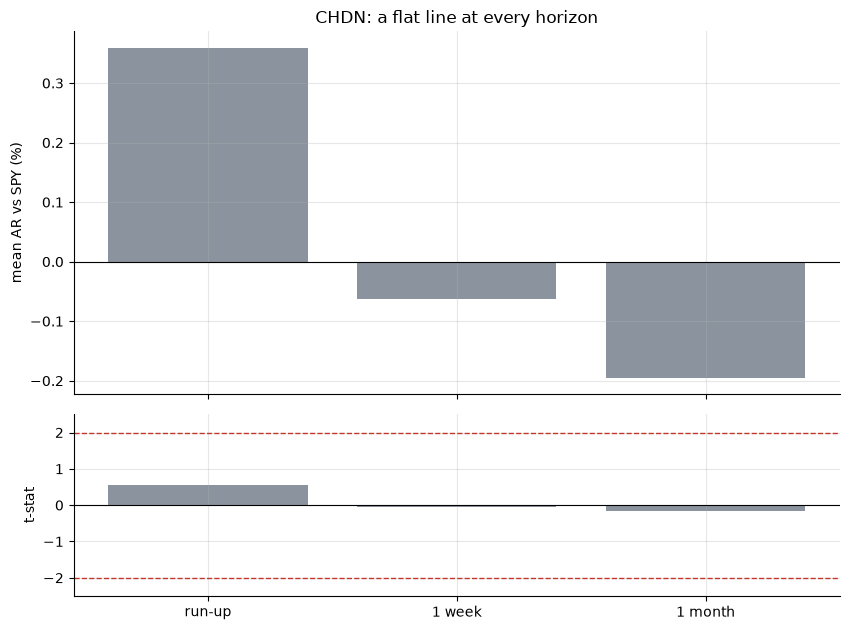

In [2]:
if HAVE_REAL:
    rows = []
    for lab, col in (('run-up','ar_runup'), ('1 week','ar_week'), ('1 month','ar_month')):
        s = st.one_sample_t(CHDN[col].values); hr = st.hit_rate(CHDN[col].values)
        rows.append((lab, s['n'], s['mean']*100, s['t'], hr['k'], hr['n']))
        print(lab, 'n=', s['n'], 'mean%', round(s['mean']*100,3), 't', round(s['t'],3),
              'hit', f"{hr['k']}/{hr['n']}")
    means = [r[2] for r in rows]; ts = [r[3] for r in rows]
else:
    means = [R['ch_ru_mean'], R['ch_wk_mean'], R['ch_mo_mean']]
    ts = [R['ch_ru_t'], R['ch_wk_t'], R['ch_mo_t']]
labels = ['run-up', '1 week', '1 month']
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.6, 6.4), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
a1.bar(labels, means, color=GREY); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('mean AR vs SPY (%)'); a1.set_title('CHDN: a flat line at every horizon')
a2.bar(labels, ts, color=[RED if abs(t)>=2 else GREY for t in ts])
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(-2, ls='--', c=RED, lw=1)
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('t-stat'); a2.set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.show()

> 💡 In plain words: run-up +0.359% (*t*=0.55), 1-week -0.063% (*t*=-0.06), 1-month -0.195% (*t*=-0.17). No horizon comes close. And the exposure-dilution caveat cuts *against* the folklore: CHDN's direct Derby exposure was largest early in the sample (pre-casino-diversification), so if anything the test is biased slightly *toward* finding an effect — and finds none.

### 4b · The gambling name's placebo — is the run-up drift unusual?

The only positive CHDN cut is the run-up (+0.36%). Redraw random same-length windows on the same tape and see where it lands.

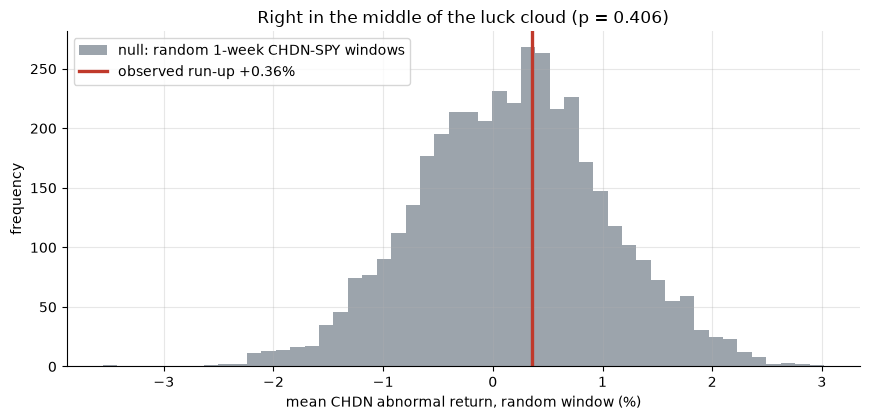

observed +0.359%, placebo mean +0.161%, p = 0.406


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(EV, PRICES, 'chdn', 'ar_runup', k=5, entry_offset=0,
                           tail='right', n_seeds=4, n_draws_per_seed=200)
    obs = pl['obs']*100
    rng = np.random.default_rng(733)
    draws = rng.normal(pl['placebo_mean'], pl['placebo_sd'], 4000)*100
else:
    obs = R['ch_ru_mean']
    rng = np.random.default_rng(733)
    draws = rng.normal(R['pl_ch_ru_plmean'], R['pl_ch_ru_plsd'], 4000)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: random 1-week CHDN-SPY windows')
ax.axvline(obs, c=RED, lw=2.4, label=f'observed run-up {obs:+.2f}%')
ax.set_xlabel('mean CHDN abnormal return, random window (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Right in the middle of the luck cloud (p = {R["pl_ch_ru_p"]:.3f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f"observed {R['ch_ru_mean']:+.3f}%, placebo mean {R['pl_ch_ru_plmean']:+.3f}%, "
      f"p = {R['pl_ch_ru_p']:.3f}")

> 💡 In plain words: *p* = 0.406 — the run-up drift is exactly what a random week produces. Nothing to see. (The 1-month cut is even further in the bulk, *p* = 0.691.)

### 4c · The market seasonal — the one soft dip, and its placebo

run-up n= 25 mean% 0.003 t 0.01 hit 12/25
1 week n= 25 mean% -0.617 t -1.426 hit 7/25
1 month n= 25 mean% -0.319 t -0.405 hit 16/25


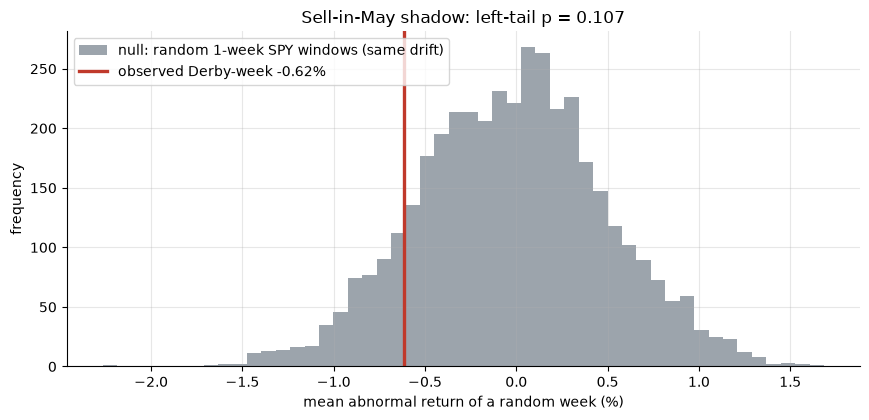

market 1-week -0.617% (t=-1.43), placebo p = 0.107


In [4]:
if HAVE_REAL:
    for lab, col in (('run-up','ar_runup'), ('1 week','ar_week'), ('1 month','ar_month')):
        s = st.one_sample_t(MKT[col].values); hr = st.hit_rate(MKT[col].values)
        print(lab, 'n=', s['n'], 'mean%', round(s['mean']*100,3), 't', round(s['t'],3),
              'hit', f"{hr['k']}/{hr['n']}")
    pl = st.placebo_pvalue(EV, PRICES, 'market', 'ar_week', k=5, entry_offset=0,
                           tail='left', n_seeds=4, n_draws_per_seed=200)
    obs = pl['obs']*100
    rng = np.random.default_rng(733); draws = rng.normal(pl['placebo_mean'], pl['placebo_sd'], 4000)*100
else:
    obs = R['mk_wk_mean']
    rng = np.random.default_rng(733); draws = rng.normal(R['pl_mk_wk_plmean'], R['pl_mk_wk_plsd'], 4000)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: random 1-week SPY windows (same drift)')
ax.axvline(obs, c=RED, lw=2.4, label=f'observed Derby-week {obs:+.2f}%')
ax.set_xlabel('mean abnormal return of a random week (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Sell-in-May shadow: left-tail p = {R["pl_mk_wk_p"]:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f"market 1-week {R['mk_wk_mean']:+.3f}% (t={R['mk_wk_t']:.2f}), placebo p = {R['pl_mk_wk_p']:.3f}")

> 💡 In plain words: the Derby-week dip is **-0.617%** (*t*=-1.43) — negative, but it doesn't clear the bar raw, and the drift-neutral placebo (*p*=0.107) says a random week is this weak roughly 1 time in 9. The 1-month cut is nothing (-0.319%, placebo *p*=0.368). This is the "Sell in May" boundary leaving a faint fingerprint, not a Derby effect.

### 4d · The jackknife — how fragile is even that soft dip?

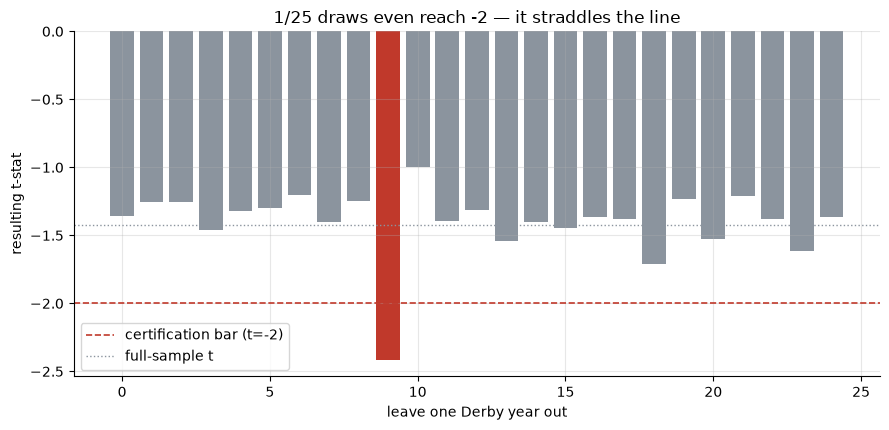

full t = -1.426; jackknife range [-2.417, -0.999]


In [5]:
if HAVE_REAL:
    x = MKT['ar_week'].values
    jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
else:
    rng = np.random.default_rng(733)
    jk = list(rng.uniform(R['jk_lo'], R['jk_hi'], R['jk_n']))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
cols = [RED if t <= -2 else GREY for t in jk]
ax.bar(range(len(jk)), jk, color=cols)
ax.axhline(-2.0, ls='--', c=RED, lw=1.2, label='certification bar (t=-2)')
ax.axhline(R['mk_wk_t'], c=GREY, lw=1, ls=':', label='full-sample t')
ax.set_xlabel('leave one Derby year out'); ax.set_ylabel('resulting t-stat')
ax.set_title(f'{R["jk_below"]}/{R["jk_n"]} draws even reach -2 — it straddles the line')
ax.legend(); plt.tight_layout(); plt.show()
print(f'full t = {R["mk_wk_t"]:.3f}; jackknife range [{min(jk):.3f}, {max(jk):.3f}]')

> 💡 In plain words: full-sample *t* = -1.426; the jackknife spans [-2.42, -1.00]. Drop the single most-positive year and it nudges past −2; keep it and it's a soft −1.4. A signal that crosses the certification line on the strength of *one* of 25 years — and had no placebo support to begin with — is textbook not-real.

### 4e · Event anatomy — the path through the race

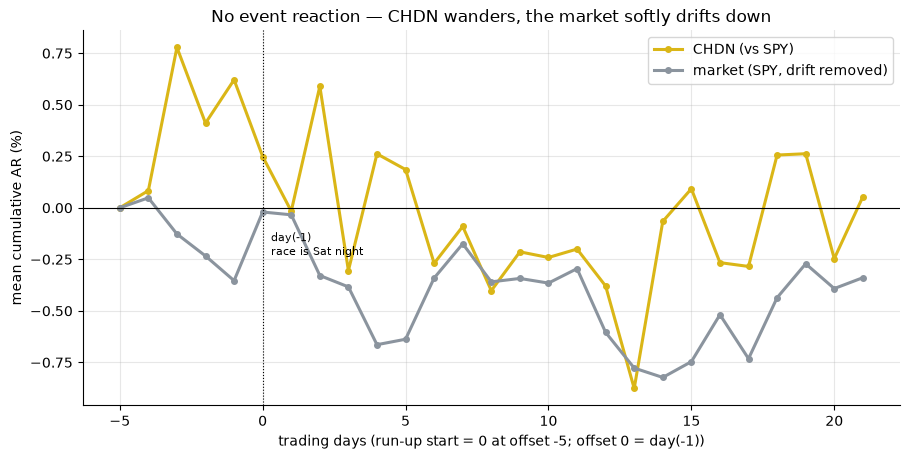

In [6]:
if HAVE_REAL:
    cp_c = st.car_path(EV, PRICES, 'chdn'); cp_m = st.car_path(EV, PRICES, 'market')
    offs = list(cp_c.index); cs = list(cp_c.values*100); ms = list(cp_m.values*100)
else:
    offs = sorted(R['car_ch']); cs = [R['car_ch'][k] for k in offs]; ms = [R['car_mk'][k] for k in offs]
fig, ax = plt.subplots(figsize=(9.2, 4.7))
ax.plot(offs, cs, color=AMBER, lw=2.2, marker='o', ms=4, label='CHDN (vs SPY)')
ax.plot(offs, ms, color=GREY, lw=2.2, marker='o', ms=4, label='market (SPY, drift removed)')
ax.axhline(0, c='k', lw=.8); ax.axvline(0, ls=':', c='k', lw=.8)
ax.annotate('day(-1)\nrace is Sat night', (0, 0), textcoords='offset points',
            xytext=(6, -34), fontsize=8, color='k')
ax.set_xlabel('trading days (run-up start = 0 at offset -5; offset 0 = day(-1))')
ax.set_ylabel('mean cumulative AR (%)')
ax.set_title('No event reaction — CHDN wanders, the market softly drifts down')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: a real event reaction would kink at day 0 and hold. CHDN drifts up into the race (peak +0.78% at day −3) and gives it all back; the market path slopes gently down across the whole window (the "Sell in May" texture, bottoming -0.75% near day +15) with no special break at the race. Two flat, directionless paths — exactly the shape of no-effect.

### 4f · Tradability — the costs-inflate-the-*t* trap, in full

Enter day(0) (post-result, zero look-ahead), net of 2× one-way cost × NAV. One cut crosses |*t*|≥2 — and it's a trap.

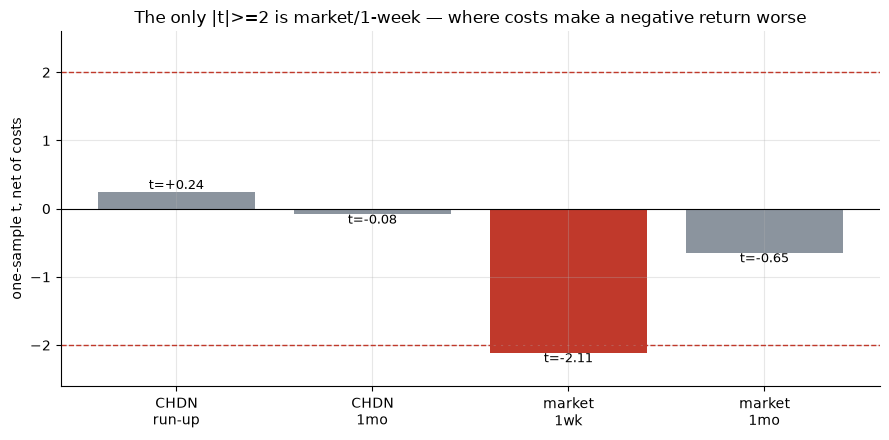

market 1wk: gross -0.60% (t=-1.58) -> net@10 -0.80% (t=-2.11), placebo p=0.111


In [7]:
labels = ['CHDN\nrun-up', 'CHDN\n1mo', 'market\n1wk', 'market\n1mo']
net = [R['ch_ru_cap_n'], R['ch_mo_cap_n'], R['mk_wk_cap_n'], R['mk_mo_cap_n']]
ts  = [R['ch_ru_cap_t'], R['ch_mo_cap_t'], R['mk_wk_cap_t'], R['mk_mo_cap_t']]
fig, ax = plt.subplots(figsize=(9.0, 4.5))
cols = [RED if abs(t)>=2 else GREY for t in ts]
bars = ax.bar(labels, ts, color=cols)
for b, t in zip(bars, ts): ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2, t),
                                       ha='center', va='bottom' if t>=0 else 'top', fontsize=9)
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('one-sample t, net of costs'); ax.set_ylim(-2.6, 2.6)
ax.set_title('The only |t|>=2 is market/1-week — where costs make a negative return worse')
plt.tight_layout(); plt.show()
print(f"market 1wk: gross {R['mk_wk_cap_g']:+.2f}% (t={R['mk_wk_cap_gt']:+.2f}) -> "
      f"net@10 {R['mk_wk_cap_n']:+.2f}% (t={R['mk_wk_cap_t']:+.2f}), placebo p={R['pl_mk_wk_cap_p']:.3f}")

> 💡 In plain words: the market/1-week return is gross **-0.60%** (*t*=-1.58). Charging a round trip of costs *deepens* it to **-0.80%** and its *t* to **-2.11** — the significance is manufactured by the cost arithmetic, not by an edge. (At 5 bps it's back under the bar: *t*=-1.85.) Its own placebo, *p*=0.111, confirms the dip is noise, and executing it means **shorting the S&P** 25 times, paying spread *and* borrow. Every honest CHDN cut is a flat ~0 net. **H3 not supported; Tradability = MIRAGE.**

### 4g · Third axis — CHDN vs the market seasonal (Welch t, May years)

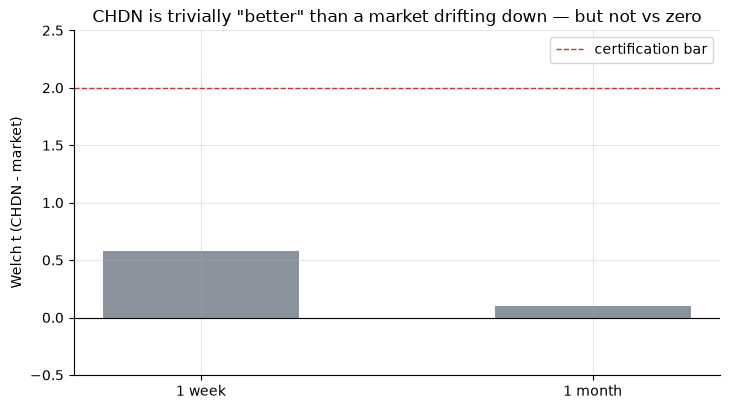

Welch t CHDN-market: 1wk +0.577, 1mo +0.103


In [8]:
if HAVE_REAL:
    chdn_may = CHDN[CHDN['ran_in_may']]
    t_wk = st.welch_t(chdn_may['ar_week'].values, MKT['ar_week'].values)
    t_mo = st.welch_t(chdn_may['ar_month'].values, MKT['ar_month'].values)
else:
    t_wk, t_mo = R['wh_wk_t'], R['wh_mo_t']
fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.bar(['1 week', '1 month'], [t_wk, t_mo], color=GREY, width=.5)
ax.axhline(2, ls='--', c=RED, lw=1, label='certification bar'); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Welch t (CHDN - market)'); ax.set_ylim(-0.5, 2.5)
ax.set_title('CHDN is trivially "better" than a market drifting down — but not vs zero')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Welch t CHDN-market: 1wk {t_wk:+.3f}, 1mo {t_mo:+.3f}')

> 💡 In plain words: Welch *t* (CHDN − market) is 0.58 (1 week) / 0.10 (1 month) — CHDN "beats" the seasonal only because the market leg is softly negative and CHDN is ~flat. Neither is distinguishable from zero on its own. **"Sell in May?" — Not supported**: the Derby week is not a market turn, and CHDN is not an event trade.

### 4h · Faithful-engine & power control

Synthetic paired (CHDN-like, SPY-like) log-return world (ρ≈0.60, CHDN idio vol > market), a scheduled synthetic first-Saturday calendar, a TUNABLE bump landing on the first session after each race. Null (bump=0) checked over **20 seeds**.

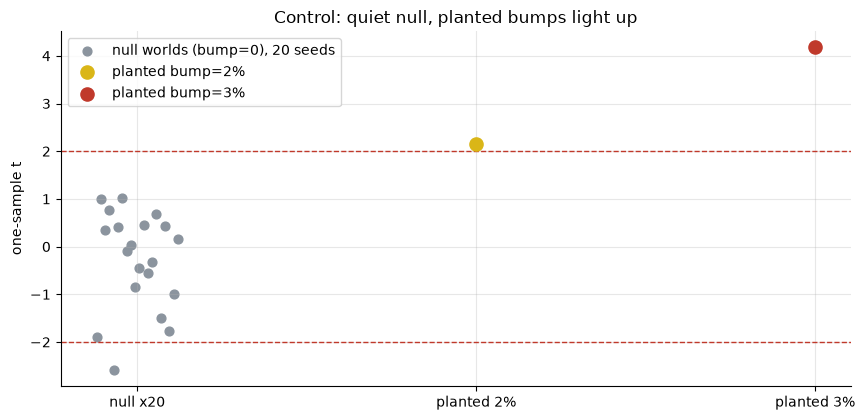

null: mean t=-0.29 (sd 1.03), |t|>=2 in 1/20 seeds
planted 2%% t=+2.16  planted 3%% t=+4.18


In [9]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=733+s, k=5)['t'] for s in range(20)])
p2 = st.synthetic_detect(bump=0.02, seed=733, k=5)
p3 = st.synthetic_detect(bump=0.03, seed=733, k=5)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (bump=0), 20 seeds')
ax.scatter([1], [p2['t']], color=AMBER, s=90, zorder=5, label='planted bump=2%')
ax.scatter([2], [p3['t']], color=RED, s=90, zorder=5, label='planted bump=3%')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['null x20', 'planted 2%', 'planted 3%'])
ax.set_ylabel('one-sample t'); ax.set_title('Control: quiet null, planted bumps light up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t={null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
print(f'planted 2%% t={p2["t"]:+.2f}  planted 3%% t={p3["t"]:+.2f}')

> 💡 In plain words: across 20 null seeds the detector averages t = -0.29 (sd 1.03) and fires at |t|≥2 in only 1/20 seeds; a planted 2% bump reads t=2.16, a 3% bump t=4.18. The machinery detects a real Derby bump when one is planted — the real-tape story is genuinely this flat. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — CHDN, the directly-exposed name, is flat at every horizon (run-up +0.359%/*t*=0.55, 1-week -0.063%/*t*=-0.06, 1-month -0.195%/*t*=-0.17, placebo *p*≥0.41) with *full* tape coverage — the cleanest kind of null, and the exposure-dilution caveat only biases toward finding an effect. The market's one whisper (1-week -0.617%, *t*=-1.43) misses the bar raw and fails its drift-neutral placebo (*p*=0.107).
- **Tradability `MIRAGE`** — no honest cut is bankable; the only |*t*|≥2 (market/1-week net, -2.11) is costs charged against an already-negative return, dies under its own placebo (*p*=0.111), and would require shorting the S&P 25 times for a dip inside the noise.
- **"Sell in May?" `NOT SUPPORTED`** — the Derby-week dip is real in sign but inside the luck cloud (*p*=0.107) and fragile to a single year (jackknife [-2.42, -1.00]).

## 6 · Going further

- **The transferable lesson is the cost trap.** When a "short this seasonal" edge gets *more* significant after costs, the costs are being charged against a negative return — the *t* is inflated, not eroded. Always re-test against a drift-neutral placebo before believing a costed short.
- **A clean null is worth publishing.** No survivorship funnel, a directly-exposed stock, full history — the ideal setup to find an effect, and it finds none. That is a stronger "no" than a data-starved one.
- **A cleaner test would need different data.** Betting-handle or attendance series, intraday moves around the actual post time, or a purpose-built gaming basket (once names like DKNG have enough history) could raise power — but the prior after this is low.
- **Dedup map:** [708-eurovision-effect](../../708-eurovision-effect/) (same machinery, survivorship story), [707-plane-crash-effect](../../707-plane-crash-effect/) (market + exposed basket, negative shock), [158-super-bowl](../../158-super-bowl/), [235-world-cup-effect](../../235-world-cup-effect/), [709-world-series-effect](../../709-world-series-effect/). None pairs a single-index seasonal with the one listed company that *operates* the event.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*